#📌 Extracción

In [55]:
import pandas as pd
import json
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

print(f" Datos cargados correctamente: {len(data)} registros")
print(type(data))

 Datos cargados correctamente: 7267 registros
<class 'list'>


In [56]:
df = pd.json_normalize(data)

df.columns = df.columns.str.replace("customer.", "", regex=False)\
                       .str.replace("phone.", "", regex=False)\
                       .str.replace("internet.", "", regex=False)\
                       .str.replace("account.", "", regex=False)\
                       .str.replace("Charges.", "Charges_", regex=False)

df["Charges_Total"] = pd.to_numeric(df["Charges_Total"], errors="coerce")

df["Churn"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nShape del DataFrame: {df.shape}")
df.head()

Valores nulos por columna:
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges_Monthly      0
Charges_Total       11
dtype: int64

Shape del DataFrame: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#🔧 Transformación

In [57]:
print("=== Columnas y tipos de datos ===")
print(df.dtypes)

print("\n=== Info general del DataFrame ===")
df.info()

print("\n=== Primeras filas ===")
df.head()

=== Columnas y tipos de datos ===
customerID           object
Churn                 int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges_Monthly     float64
Charges_Total       float64
dtype: object

=== Info general del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-n

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [58]:
print("=== Valores nulos por columna ===")
print(df.isnull().sum())

print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")

categoricas = df.select_dtypes(include="object").columns
print("\n=== Valores únicos por columna categórica ===")
for col in categoricas:
    print(f"\n{col}: {df[col].unique()}")

=== Valores nulos por columna ===
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges_Monthly      0
Charges_Total       11
dtype: int64

=== Filas duplicadas: 0 ===

=== Valores únicos por columna categórica ===

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['Yes' 'No']

PhoneService: ['Yes' 'No']

MultipleLines: ['No' 'Yes' 'No phone service']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service

In [59]:
df = df.drop_duplicates()
print(f"Registros tras eliminar duplicados: {len(df)}")

df["Charges_Total"] = df["Charges_Total"].fillna(df["Charges_Total"].median())

print("\nValores nulos restantes:")
print(df.isnull().sum())

Registros tras eliminar duplicados: 7267

Valores nulos restantes:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges_Monthly     0
Charges_Total       0
dtype: int64


In [60]:
df["Cuentas_Diarias"] = (df["Charges_Monthly"] / 30).round(2)

print("=== Columna 'Cuentas_Diarias' creada ===")
df[["customerID", "Charges_Monthly", "Cuentas_Diarias"]].head()

=== Columna 'Cuentas_Diarias' creada ===


,customerID,Charges_Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [61]:
cols_binarias = [
    "Partner", "Dependents", "PhoneService", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling"
]

for col in cols_binarias:
    df[col] = df[col].map({"Yes": 1, "No": 0, "No phone service": 0, "No internet service": 0})

df["InternetService"] = df["InternetService"].map({
    "DSL": "DSL",
    "Fiber optic": "Fibra óptica",
    "No": "Sin internet"
})

df["Contract"] = df["Contract"].map({
    "Month-to-month": "Mes a mes",
    "One year": "Un año",
    "Two year": "Dos años"
})

df["PaymentMethod"] = df["PaymentMethod"].map({
    "Electronic check": "Cheque electrónico",
    "Mailed check": "Cheque por correo",
    "Bank transfer (automatic)": "Transferencia bancaria",
    "Credit card (automatic)": "Tarjeta de crédito"
})

df = df.rename(columns={
    "customerID": "ID_Cliente",
    "Churn": "Evasion",
    "gender": "Genero",
    "SeniorCitizen": "Adulto_Mayor",
    "Partner": "Pareja",
    "Dependents": "Dependientes",
    "tenure": "Meses_Contrato",
    "PhoneService": "Servicio_Telefono",
    "MultipleLines": "Multiples_Lineas",
    "InternetService": "Servicio_Internet",
    "OnlineSecurity": "Seguridad_Online",
    "OnlineBackup": "Respaldo_Online",
    "DeviceProtection": "Proteccion_Dispositivo",
    "TechSupport": "Soporte_Tecnico",
    "StreamingTV": "Streaming_TV",
    "StreamingMovies": "Streaming_Peliculas",
    "Contract": "Tipo_Contrato",
    "PaperlessBilling": "Factura_Digital",
    "PaymentMethod": "Metodo_Pago",
    "Charges_Monthly": "Cargo_Mensual",
    "Charges_Total": "Cargo_Total"
})

df["Genero"] = df["Genero"].map({"Male": "Masculino", "Female": "Femenino"})

print(" Estandarización completada")
print(df.dtypes)
df.head()

 Estandarización completada
ID_Cliente                 object
Evasion                     int64
Genero                     object
Adulto_Mayor                int64
Pareja                      int64
Dependientes                int64
Meses_Contrato              int64
Servicio_Telefono           int64
Multiples_Lineas            int64
Servicio_Internet          object
Seguridad_Online            int64
Respaldo_Online             int64
Proteccion_Dispositivo      int64
Soporte_Tecnico             int64
Streaming_TV                int64
Streaming_Peliculas         int64
Tipo_Contrato              object
Factura_Digital             int64
Metodo_Pago                object
Cargo_Mensual             float64
Cargo_Total               float64
Cuentas_Diarias           float64
dtype: object


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Un año,1,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra óptica,...,1,0,0,0,Mes a mes,1,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra óptica,...,1,0,1,1,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fibra óptica,...,0,1,1,0,Mes a mes,1,Cheque por correo,83.9,267.40,2.80


#📊 Carga y análisis

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

print("=== Estadísticas Descriptivas ===")
df[["Meses_Contrato", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"]].describe().T\
    .rename(columns={"mean": "Media", "50%": "Mediana", "std": "Desv_Std",
                     "min": "Mínimo", "max": "Máximo"})


=== Estadísticas Descriptivas ===


,count,Media,Desv_Std,Mínimo,25%,Mediana,75%,Máximo
Meses_Contrato,7267.0,32.346498,24.571773,0.00,9.000,29.00,55.000,72.00
Cargo_Mensual,7267.0,64.720098,30.129572,18.25,35.425,70.30,89.875,118.75
Cargo_Total,7267.0,2279.287581,2267.178963,18.80,401.400,1391.00,3778.525,8684.80
Cuentas_Diarias,7267.0,2.157292,1.004407,0.61,1.180,2.34,2.995,3.96


In [63]:
print("=== Medianas ===")
print(df[["Meses_Contrato", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"]].median())

=== Medianas ===
Meses_Contrato       29.00
Cargo_Mensual        70.30
Cargo_Total        1391.00
Cuentas_Diarias       2.34
dtype: float64


=== Distribución de Evasión ===
         Cantidad  Porcentaje (%)
Evasion                          
0            5398           74.28
1            1869           25.72


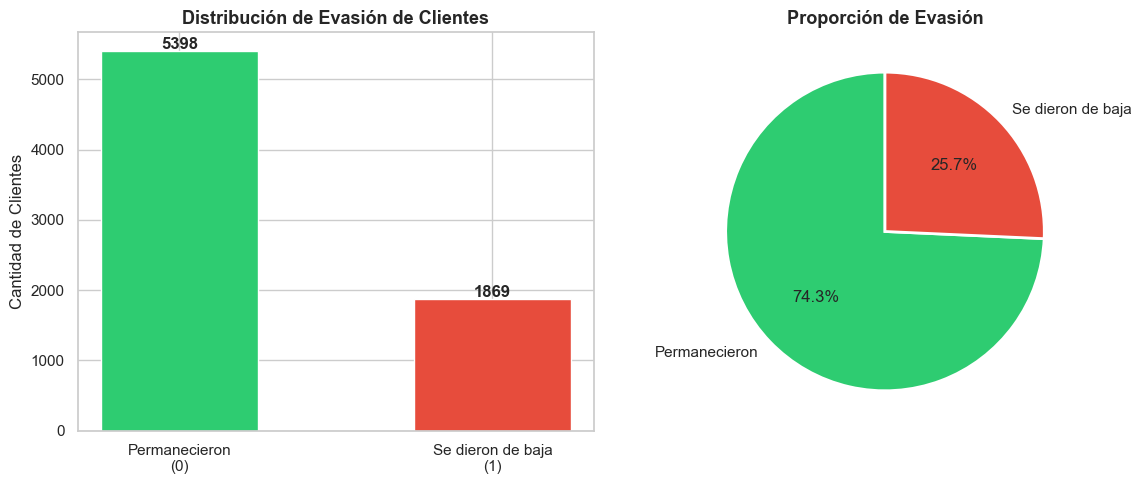

In [64]:
conteo_evasion = df["Evasion"].value_counts()
porcentaje_evasion = df["Evasion"].value_counts(normalize=True) * 100

print("=== Distribución de Evasión ===")
print(pd.DataFrame({"Cantidad": conteo_evasion, "Porcentaje (%)": porcentaje_evasion.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    ["Permanecieron\n(0)", "Se dieron de baja\n(1)"],
    conteo_evasion.values,
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Distribución de Evasión de Clientes", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Cantidad de Clientes")
for i, v in enumerate(conteo_evasion.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(
    conteo_evasion.values,
    labels=["Permanecieron", "Se dieron de baja"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporción de Evasión", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

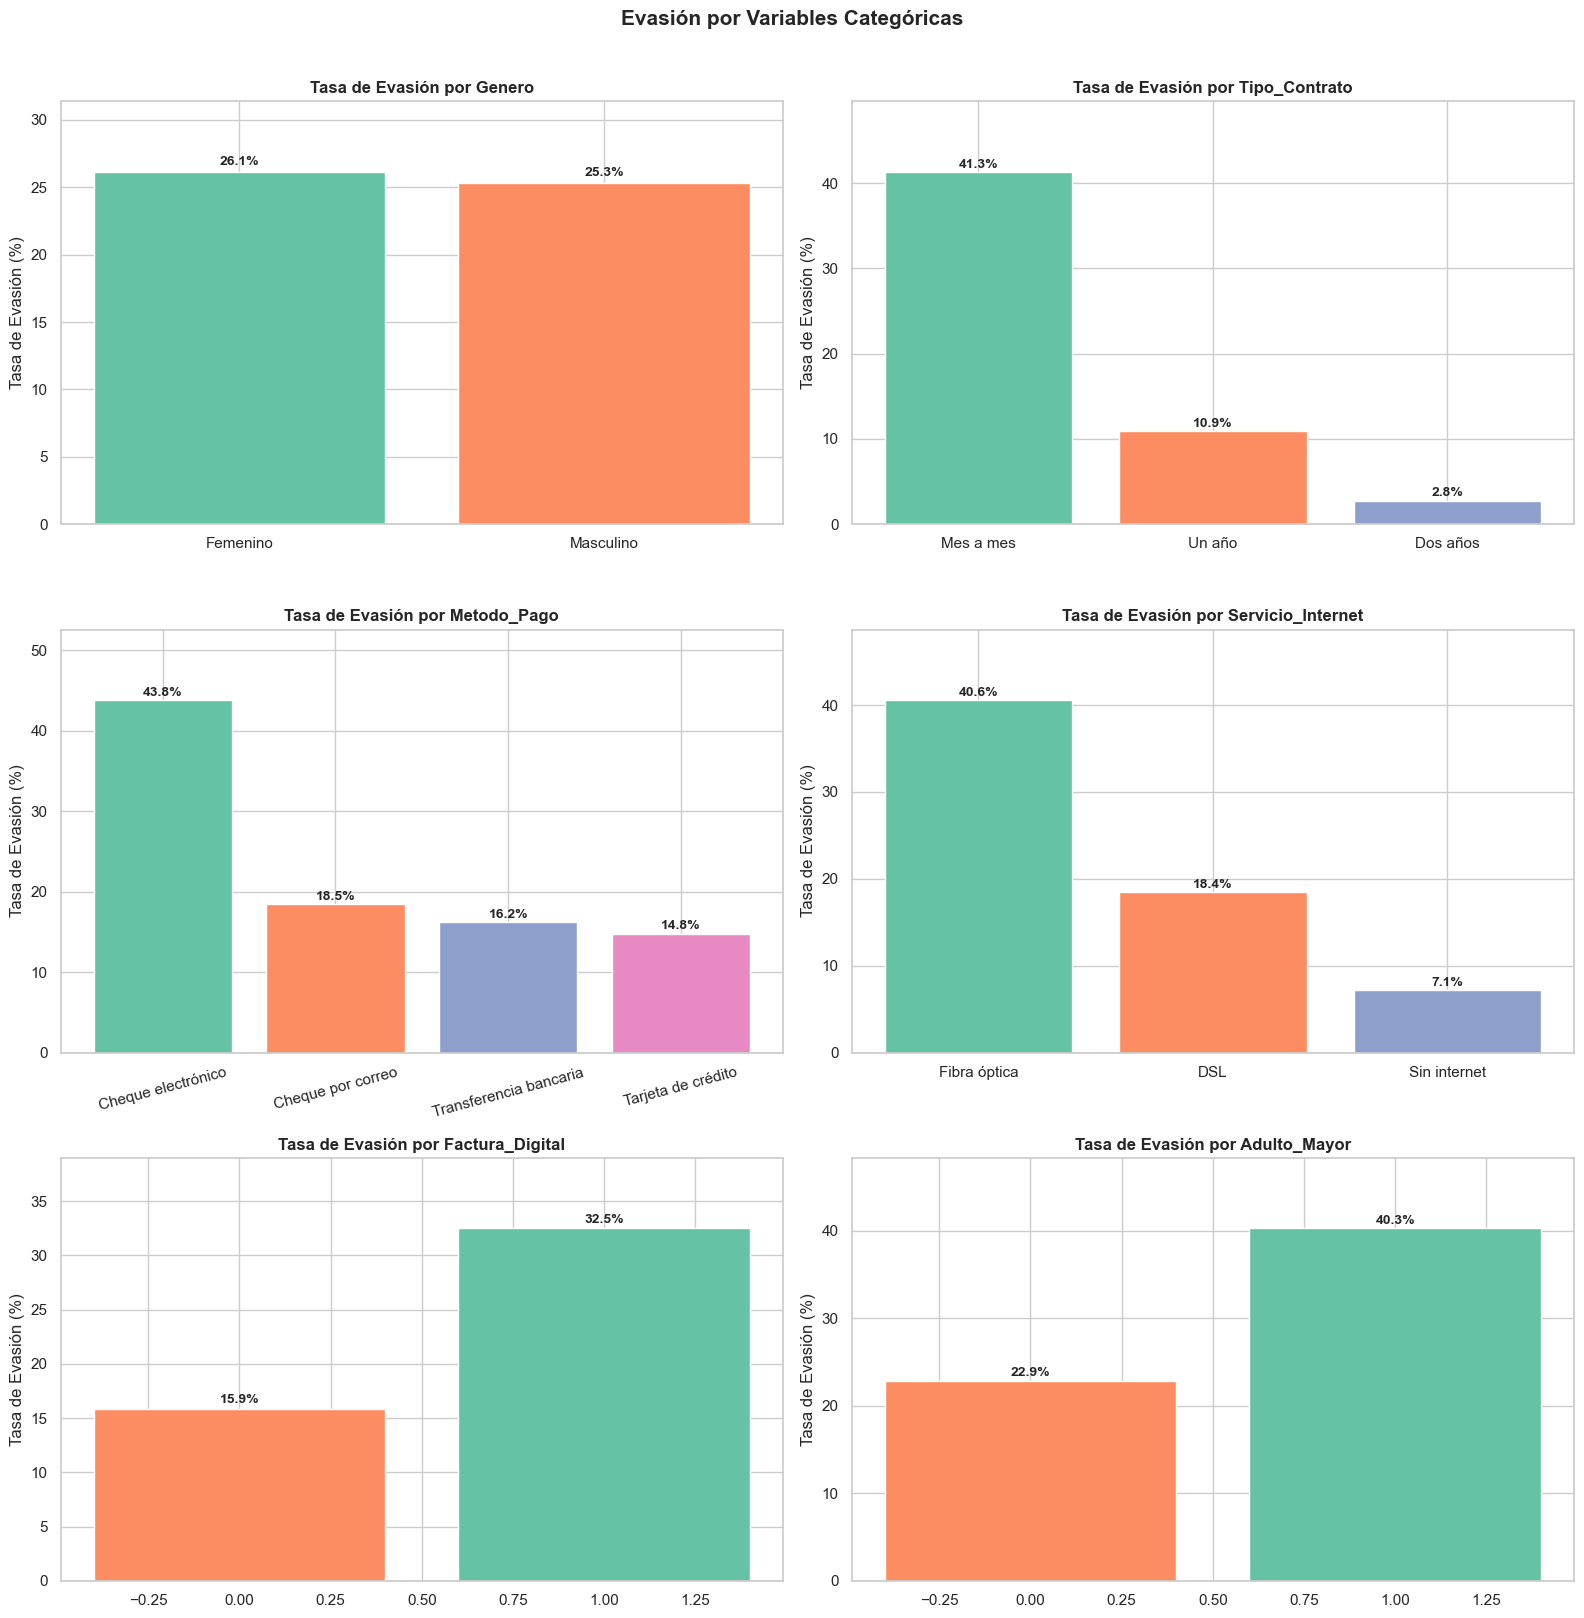

In [65]:
vars_categoricas = ["Genero", "Tipo_Contrato", "Metodo_Pago", 
                    "Servicio_Internet", "Factura_Digital", "Adulto_Mayor"]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, var in enumerate(vars_categoricas):
    tabla = df.groupby(var)["Evasion"].mean().reset_index()
    tabla["Evasion_pct"] = tabla["Evasion"] * 100
    tabla = tabla.sort_values("Evasion_pct", ascending=False)

    bars = axes[i].bar(
        tabla[var],
        tabla["Evasion_pct"],
        color=sns.color_palette("Set2", len(tabla)),
        edgecolor="white"
    )
    axes[i].set_title(f"Tasa de Evasión por {var}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Tasa de Evasión (%)")
    axes[i].set_ylim(0, tabla["Evasion_pct"].max() * 1.2)

    for bar, val in zip(bars, tabla["Evasion_pct"]):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", fontsize=10, fontweight="bold"
        )

    if df[var].nunique() > 3:
        axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Evasión por Variables Categóricas", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

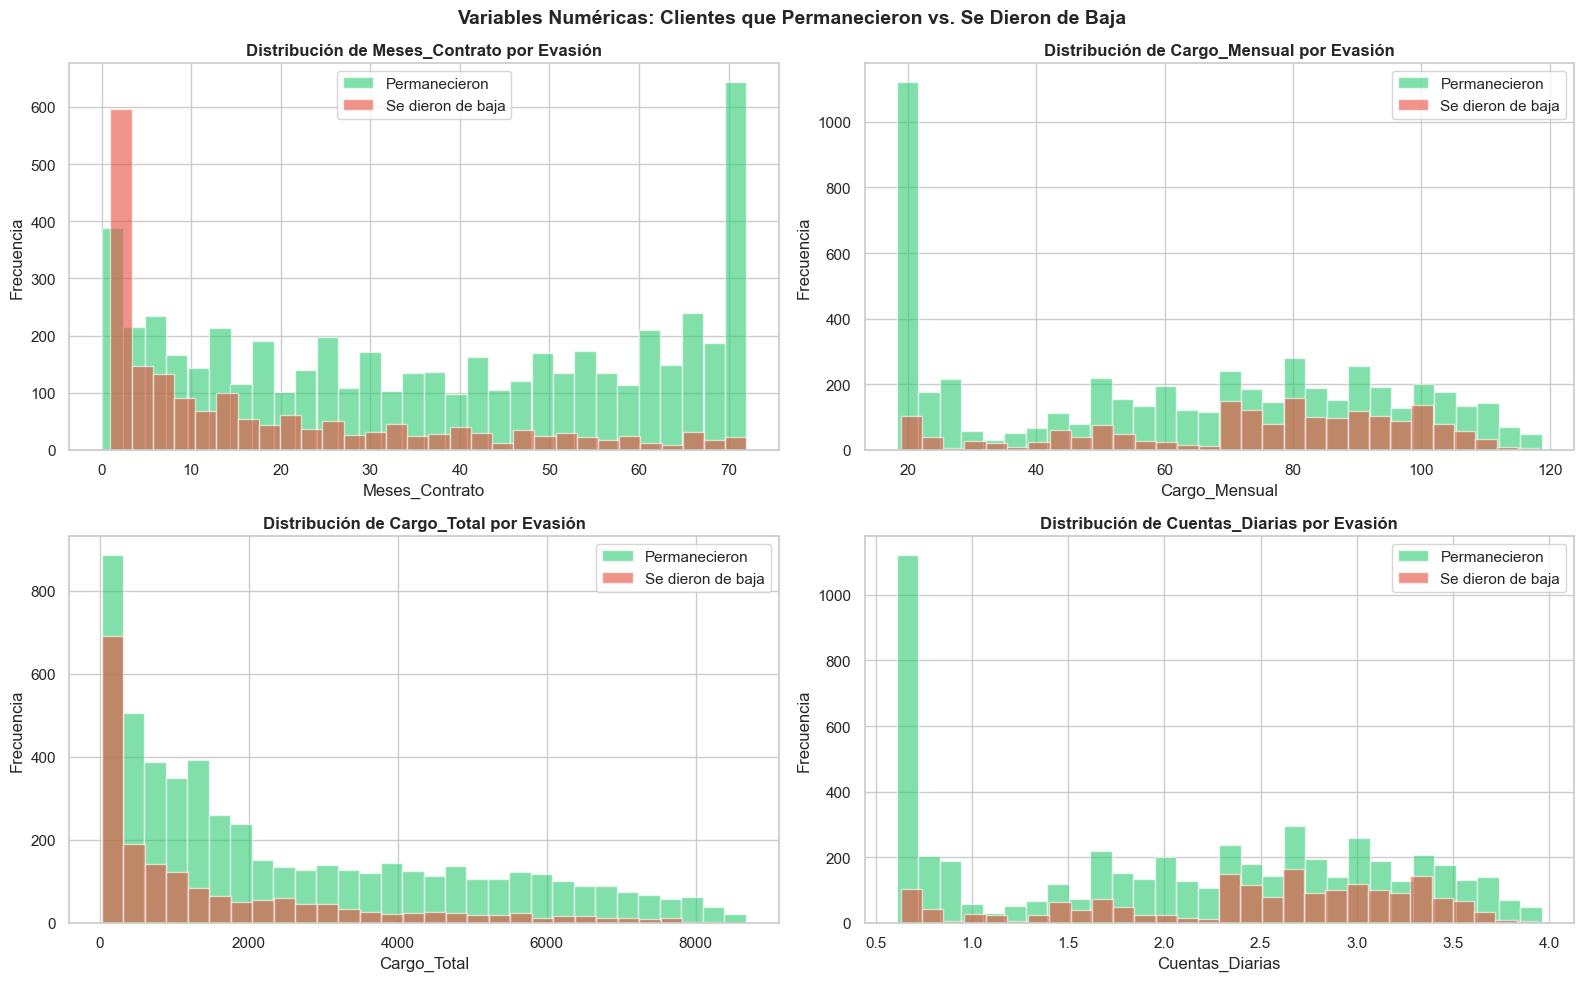

In [66]:
vars_numericas = ["Meses_Contrato", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"]
labels_evasion = {0: "Permanecieron", 1: "Se dieron de baja"}
colores = {0: "#2ecc71", 1: "#e74c3c"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    for grupo in [0, 1]:
        subset = df[df["Evasion"] == grupo][var]
        axes[i].hist(
            subset,
            bins=30,
            alpha=0.6,
            label=labels_evasion[grupo],
            color=colores[grupo],
            edgecolor="white"
        )
    axes[i].set_title(f"Distribución de {var} por Evasión", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend()

plt.suptitle("Variables Numéricas: Clientes que Permanecieron vs. Se Dieron de Baja",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

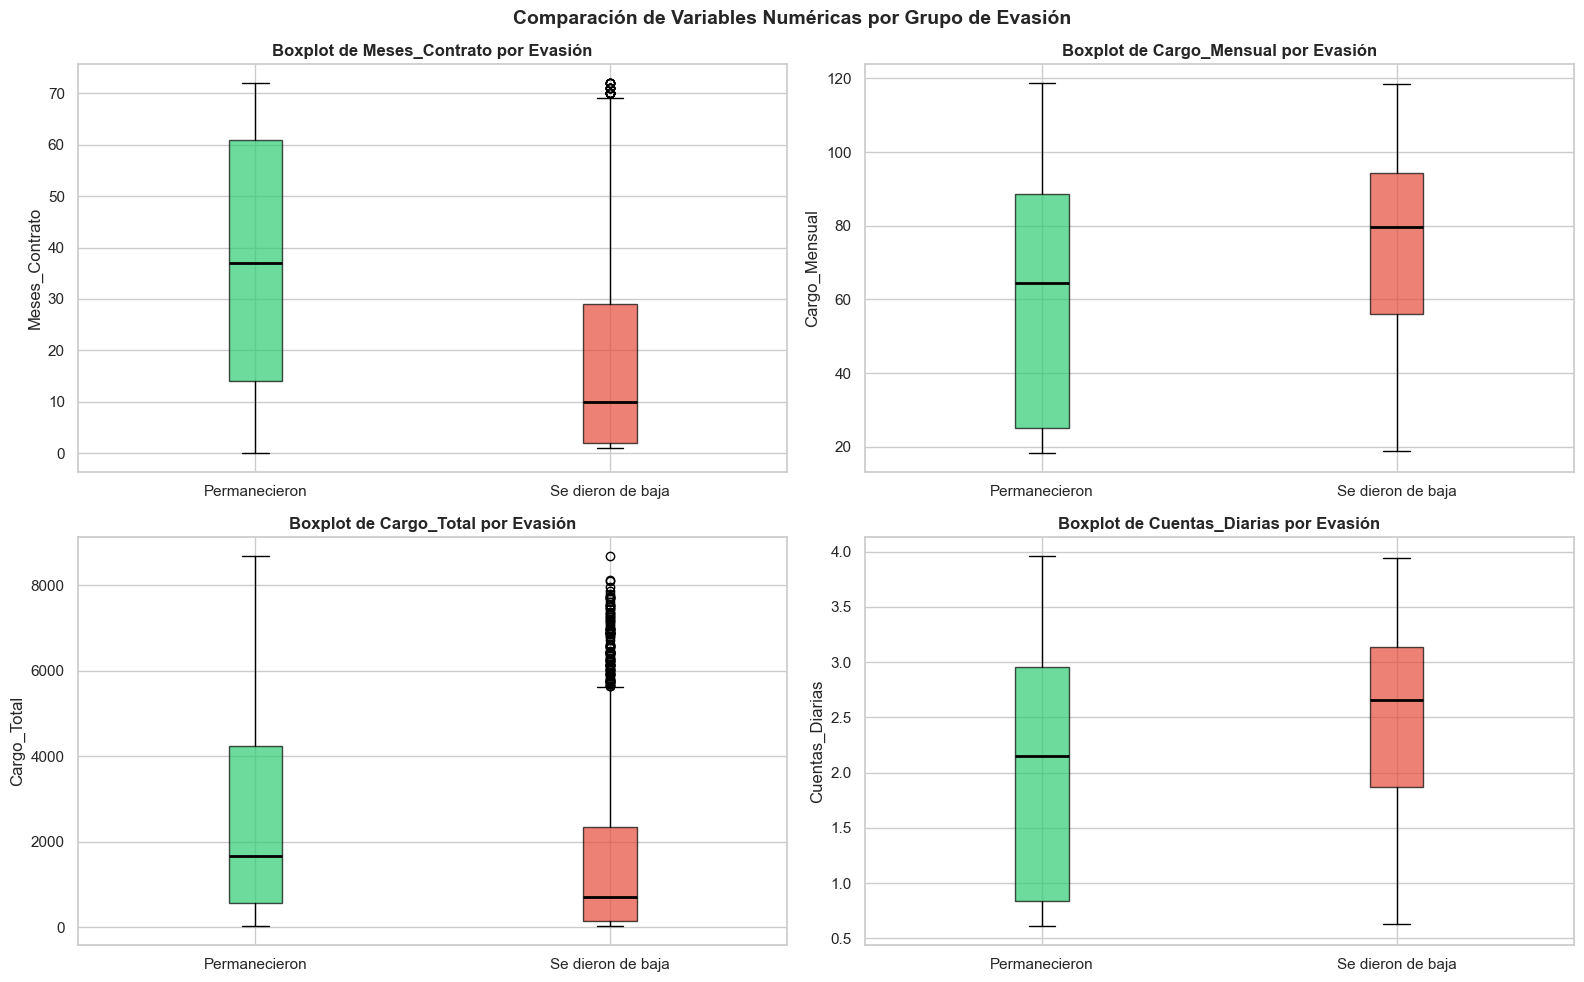

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    data_grupos = [df[df["Evasion"] == g][var].dropna() for g in [0, 1]]
    bp = axes[i].boxplot(
        data_grupos,
        labels=["Permanecieron", "Se dieron de baja"],
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2}
    )
    for patch, color in zip(bp["boxes"], ["#2ecc71", "#e74c3c"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(f"Boxplot de {var} por Evasión", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(var)

plt.suptitle("Comparación de Variables Numéricas por Grupo de Evasión",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#📄Informe final


---
# Informe Final — Análisis de Evasión de Clientes (Churn)
### TelecomX LATAM | Análisis de Datos



##  1. Introducción

**TelecomX** enfrenta un desafío crítico: la pérdida de clientes o **churn**, que ocurre cuando 
un cliente decide cancelar sus servicios y migrar a la competencia.

Este fenómeno tiene un impacto directo en los ingresos y la sostenibilidad del negocio, ya que 
**adquirir un nuevo cliente cuesta entre 5 y 7 veces más** que retener uno existente.

###  Objetivo
Identificar los **factores que impulsan la evasión de clientes** mediante el análisis exploratorio 
de datos demográficos, servicios contratados y patrones de facturación, con el fin de proponer 
estrategias de retención basadas en evidencia.

### Fuente de Datos
- **Origen:** API de TelecomX (formato JSON)
- **Registros analizados:** ~7,000 clientes
- **Variables:** 21 columnas (demográficas, servicios, contrato y facturación)




##  2. Limpieza y Tratamiento de Datos

### Extracción
- Datos cargados directamente desde la API en formato JSON usando `requests`.
- El JSON tenía estructura **anidada** (sub-objetos: `customer`, `phone`, `internet`, `account`), 
  que fue aplanada con `pd.json_normalize()`.

### Transformaciones realizadas

| Problema detectado | Solución aplicada |
|---|---|
| JSON anidado | Aplanado con `pd.json_normalize()` |
| `Charges_Total` con strings vacíos | Convertido a numérico, nulos rellenados con la mediana |
| Filas duplicadas | Eliminadas con `drop_duplicates()` |
| Variables binarias (Yes/No) | Convertidas a valores numéricos (1/0) |
| Columnas en inglés | Renombradas al español para mayor claridad |
| Categorías de texto | Traducidas al español (género, contrato, método de pago) |

###  Nueva variable creada
- **`Cuentas_Diarias`** = `Cargo_Mensual / 30` → Permite analizar el gasto diario del cliente.



##  3. Análisis Exploratorio de Datos (EDA)

A continuación se presentan los principales análisis realizados con sus visualizaciones.



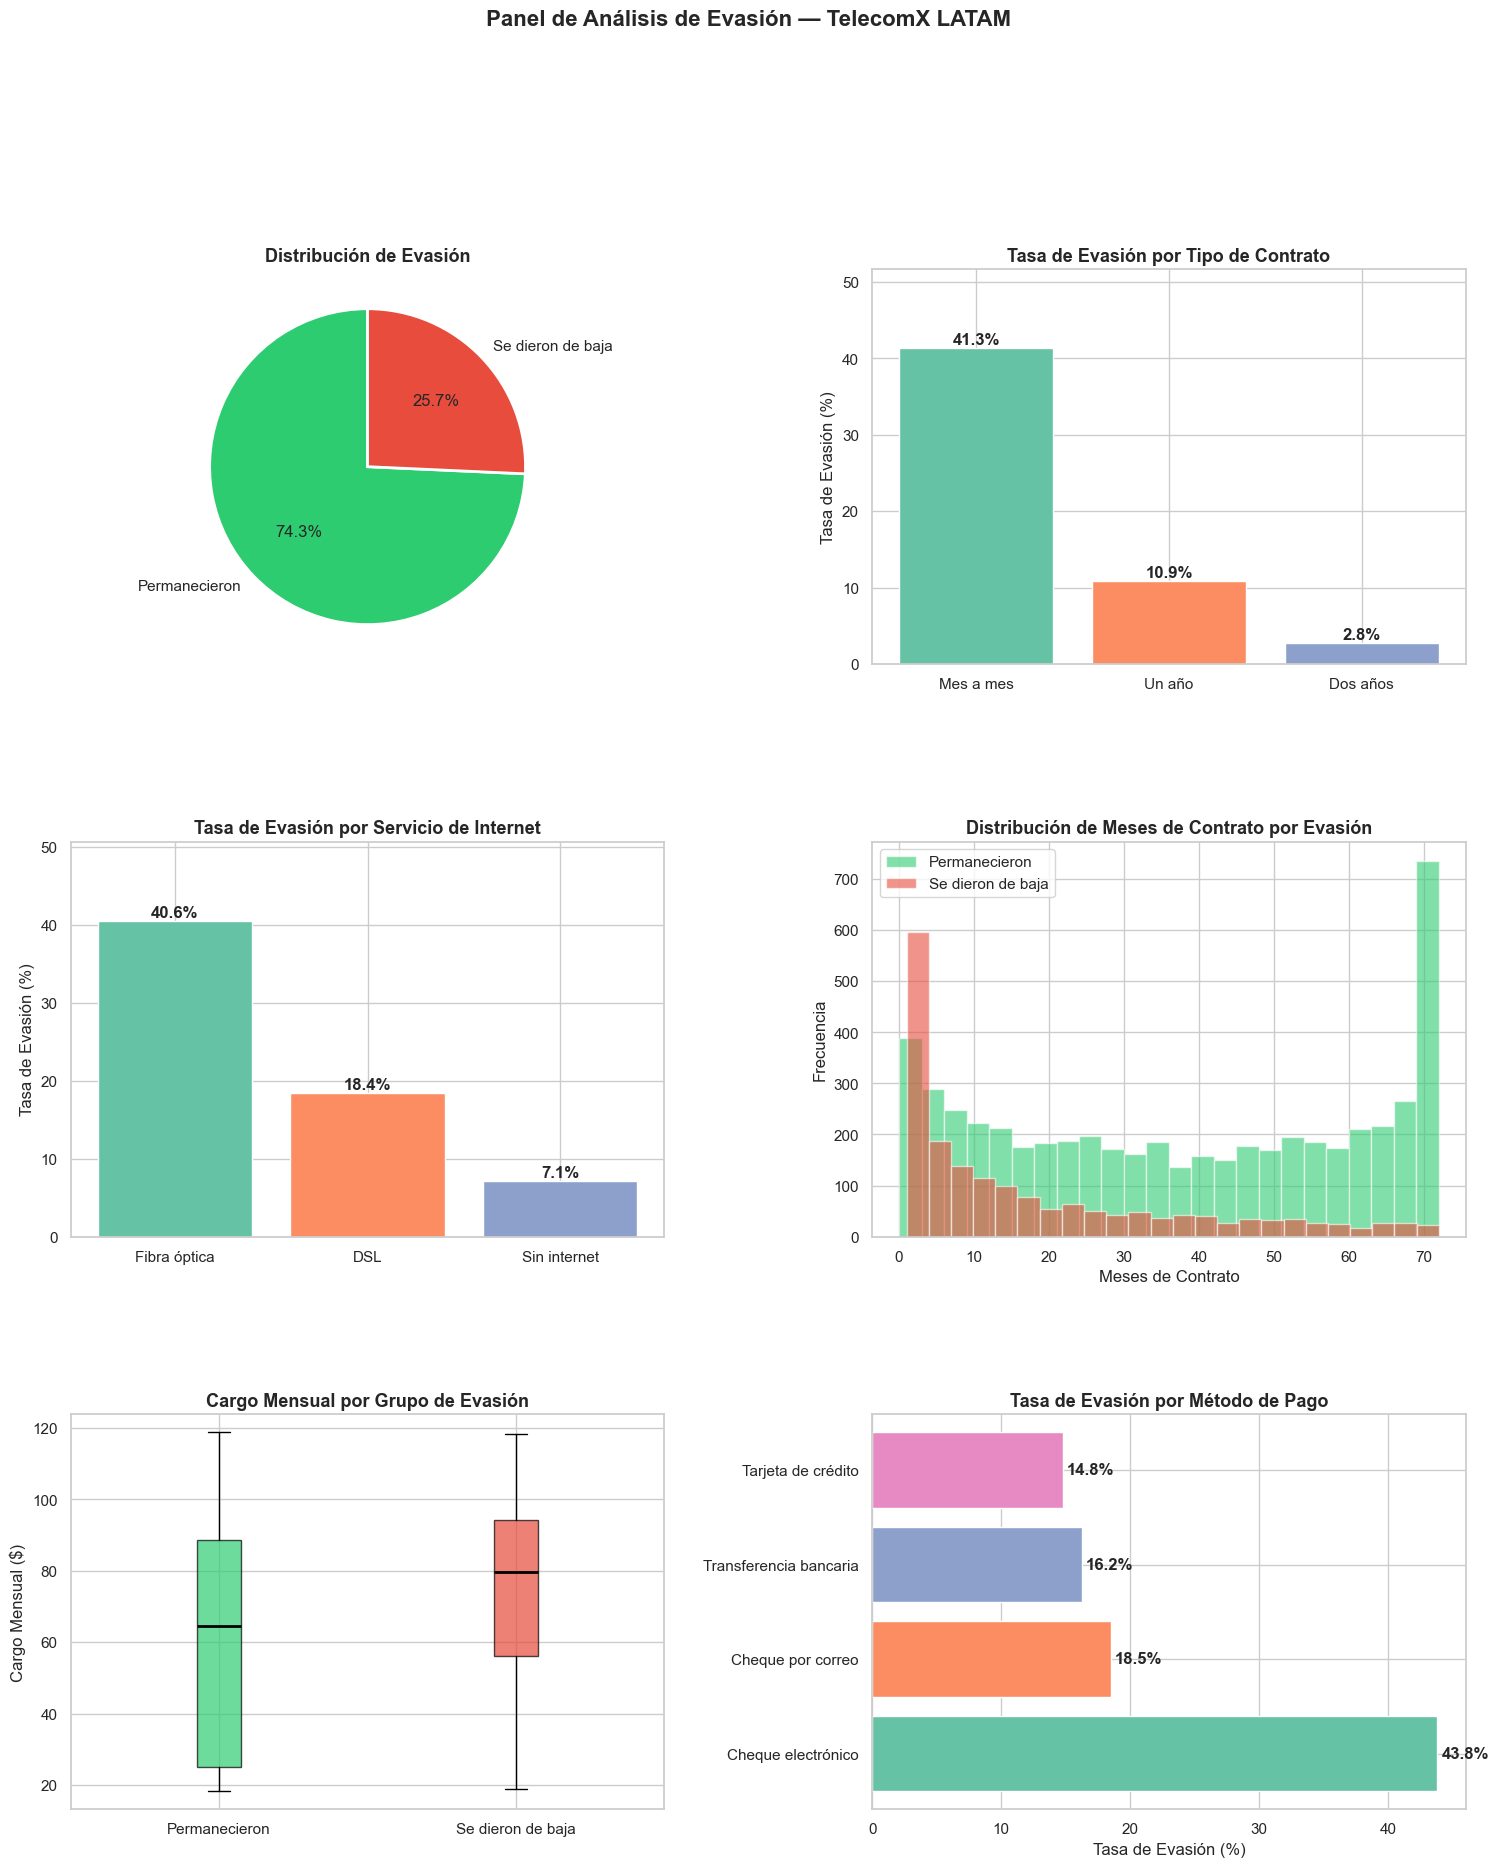

 Panel guardado como 'panel_evasion.png'


In [68]:


sns.set_theme(style="whitegrid", palette="Set2")

fig = plt.figure(figsize=(18, 20))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

colores = ["#2ecc71", "#e74c3c"]

# --- Gráfico 1: Distribución Churn (torta) ---
ax1 = fig.add_subplot(gs[0, 0])
conteo = df["Evasion"].value_counts()
ax1.pie(conteo.values, labels=["Permanecieron", "Se dieron de baja"],
        autopct="%1.1f%%", colors=colores, startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax1.set_title("Distribución de Evasión", fontsize=13, fontweight="bold")

# --- Gráfico 2: Evasión por Tipo de Contrato ---
ax2 = fig.add_subplot(gs[0, 1])
tabla_contrato = df.groupby("Tipo_Contrato")["Evasion"].mean().sort_values(ascending=False) * 100
bars = ax2.bar(tabla_contrato.index, tabla_contrato.values,
               color=sns.color_palette("Set2", len(tabla_contrato)), edgecolor="white")
ax2.set_title("Tasa de Evasión por Tipo de Contrato", fontsize=13, fontweight="bold")
ax2.set_ylabel("Tasa de Evasión (%)")
ax2.set_ylim(0, tabla_contrato.max() * 1.25)
for bar, val in zip(bars, tabla_contrato.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontweight="bold")

# --- Gráfico 3: Evasión por Servicio de Internet ---
ax3 = fig.add_subplot(gs[1, 0])
tabla_internet = df.groupby("Servicio_Internet")["Evasion"].mean().sort_values(ascending=False) * 100
bars3 = ax3.bar(tabla_internet.index, tabla_internet.values,
                color=sns.color_palette("Set2", len(tabla_internet)), edgecolor="white")
ax3.set_title("Tasa de Evasión por Servicio de Internet", fontsize=13, fontweight="bold")
ax3.set_ylabel("Tasa de Evasión (%)")
ax3.set_ylim(0, tabla_internet.max() * 1.25)
for bar, val in zip(bars3, tabla_internet.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontweight="bold")

# --- Gráfico 4: Meses de Contrato por Evasión ---
ax4 = fig.add_subplot(gs[1, 1])
for grupo, color, label in zip([0, 1], colores, ["Permanecieron", "Se dieron de baja"]):
    ax4.hist(df[df["Evasion"] == grupo]["Meses_Contrato"],
             bins=24, alpha=0.6, color=color, label=label, edgecolor="white")
ax4.set_title("Distribución de Meses de Contrato por Evasión", fontsize=13, fontweight="bold")
ax4.set_xlabel("Meses de Contrato")
ax4.set_ylabel("Frecuencia")
ax4.legend()

# --- Gráfico 5: Cargo Mensual por Evasión (boxplot) ---
ax5 = fig.add_subplot(gs[2, 0])
data_box = [df[df["Evasion"] == g]["Cargo_Mensual"].dropna() for g in [0, 1]]
bp = ax5.boxplot(data_box, labels=["Permanecieron", "Se dieron de baja"],
                 patch_artist=True, medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_title("Cargo Mensual por Grupo de Evasión", fontsize=13, fontweight="bold")
ax5.set_ylabel("Cargo Mensual ($)")

# --- Gráfico 6: Evasión por Método de Pago ---
ax6 = fig.add_subplot(gs[2, 1])
tabla_pago = df.groupby("Metodo_Pago")["Evasion"].mean().sort_values(ascending=False) * 100
bars6 = ax6.barh(tabla_pago.index, tabla_pago.values,
                 color=sns.color_palette("Set2", len(tabla_pago)), edgecolor="white")
ax6.set_title("Tasa de Evasión por Método de Pago", fontsize=13, fontweight="bold")
ax6.set_xlabel("Tasa de Evasión (%)")
for bar, val in zip(bars6, tabla_pago.values):
    ax6.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontweight="bold")

plt.suptitle(" Panel de Análisis de Evasión — TelecomX LATAM",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("panel_evasion.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Panel guardado como 'panel_evasion.png'")


##  4. Conclusiones e Insights

###  Hallazgos Principales

####  Tasa de evasión general
- Aproximadamente el **26% de los clientes** cancelaron el servicio, lo que representa 
  un volumen significativo de pérdida de ingresos.

####  Tipo de Contrato — Factor más crítico
- Los clientes con contrato **mes a mes** presentan la tasa de evasión más alta (~43%).
- Los contratos **anuales y bianuales** muestran tasas de evasión inferiores al 10%.
- → Los clientes sin compromiso a largo plazo son los más vulnerables.

####  Servicio de Internet
- Los usuarios de **Fibra Óptica** tienen una tasa de evasión significativamente mayor 
  que los de DSL o sin internet.
- → Puede indicar problemas de calidad/precio en este segmento.

####  Método de Pago
- Los clientes que pagan con **cheque electrónico** tienen la mayor tasa de evasión (~45%).
- Los métodos automáticos (transferencia bancaria, tarjeta de crédito) muestran tasas mucho menores.
- → El pago manual puede ser síntoma de menor compromiso con el servicio.

####  Tiempo de Contrato (Meses)
- Clientes con **poco tiempo de contrato** (0-12 meses) concentran la mayoría de las evasiones.
- Clientes con más de 24 meses tienen tasas de evasión muy bajas.
- → El primer año es el período crítico de retención.

####  Cargo Mensual
- Los clientes que se dieron de baja pagaban en promedio **cargos mensuales más altos**.
- → El precio percibido puede no estar alineado con el valor del servicio.



## 5 . Recomendaciones Estratégicas

###  Acciones sugeridas para reducir la evasión

| Prioridad | Estrategia | Justificación |
|-----------|-----------|---------------|
|  Alta | **Incentivar contratos anuales o bianuales** con descuentos o beneficios exclusivos | Son los que menor evasión presentan |
|  Alta | **Programa de fidelización en los primeros 12 meses** (descuentos, soporte prioritario) | La mayor evasión ocurre en el primer año |
|  Media | **Revisar la experiencia del servicio de Fibra Óptica** (velocidad, estabilidad, soporte) | Alta evasión en este segmento pese a ser premium |
|  Media | **Migrar clientes a métodos de pago automático** con incentivos (mes gratis, cashback) | Pagos automáticos correlacionan con mayor retención |
|  Normal | **Segmentar campañas de retención** por perfil de riesgo (mes a mes + alto cargo + poco tiempo) | Focaliza recursos en clientes más propensos a irse |
|  Normal | **Revisar la propuesta de valor para clientes de alto cargo mensual** | Precio alto sin valor percibido impulsa la salida |

###  Próximos Pasos Sugeridos
1. Construir un **modelo predictivo de churn** (Regresión Logística, Random Forest) para identificar 
   clientes en riesgo antes de que se vayan.
2. Diseñar un **dashboard en tiempo real** que monitoree la tasa de evasión por segmento.
3. Implementar **encuestas de satisfacción** a los 3, 6 y 12 meses de contrato.
